In [1]:
"""
Functional TIME SERIES simulation + FPCA and FAE + time series analysis 

Dependencies:
  numpy, torch, matplotlib, scikit-learn
"""

from __future__ import annotations

import math
import random
from dataclasses import dataclass
from typing import Dict, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# ============================================================
# 0) Repro / metrics / utilities
# ============================================================

def set_seed(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def rel_mse(y_hat: torch.Tensor, y_true: torch.Tensor, eps: float = 1e-12) -> float:
    """
    relMSE = MSE / Var(y_true)
    """
    m = torch.mean((y_hat - y_true) ** 2)
    v = torch.var(y_true, unbiased=False)
    return float((m / v.clamp_min(eps)).detach().cpu())

def trapezoid_weights(x: np.ndarray) -> torch.Tensor:
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)
    if len(dx) < 1:
        raise ValueError("Need at least 2 grid points.")
    w = np.zeros_like(x)
    w[0] = dx[0] / 2.0
    w[-1] = dx[-1] / 2.0
    if len(x) > 2:
        w[1:-1] = (x[2:] - x[:-2]) / 2.0
    return torch.tensor(w, dtype=torch.float32)

# Test and Train Splitting (kepping horizonal curves for forecasting)
def chrono_split(X: torch.Tensor, horizon: int) -> Tuple[torch.Tensor, torch.Tensor]:
    if horizon < 1:
        raise ValueError("horizon must be >= 1")
    return X[:-horizon], X[-horizon:]

def print_report_table(title: str, rows: Dict[str, Dict[str, float]]) -> None:
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))
    header = f"{'Method':<14}  {'relMSE vs CLEAN':>16}  {'relMSE vs NOISY':>16}"
    print(header)
    print("-" * len(header))
    for method, vals in rows.items():
        a = vals.get("relMSE_vs_clean", float("nan"))
        b = vals.get("relMSE_vs_noisy", float("nan"))
        print(f"{method:<14}  {a:16.6f}  {b:16.6f}")


# ============================================================
# 1) Basis builder (Fourier / Bspline)
# ============================================================

class BasisFCBuilder:
    """
    Build basis matrix evaluated on tpts.
    Output shape: [n_time, n_basis]
    """
    def __init__(self, n_basis=20, basis_type="Fourier", custom_basis_fn=None, bspline_degree=3):
        self.n_basis = int(n_basis)
        self.basis_type = basis_type
        self.basis_type_l = basis_type.lower()
        self.custom_basis_fn = custom_basis_fn
        self.bspline_degree = int(bspline_degree)

    def build(self, tpts: torch.Tensor) -> torch.Tensor:
        if self.custom_basis_fn is not None:
            B = self.custom_basis_fn(tpts)
            if not torch.is_tensor(B):
                B = torch.tensor(B, dtype=torch.float32)
            return B.float()

        if self.basis_type_l == "fourier":
            return self._build_fourier(tpts)
        elif self.basis_type_l in ("bspline", "b-spline", "b_spline"):
            return self._build_bspline(tpts, degree=self.bspline_degree)
        else:
            raise ValueError("basis_type must be 'Fourier' or 'Bspline'.")

    def _build_fourier(self, tpts: torch.Tensor) -> torch.Tensor:
        t = tpts.flatten()
        t_min = t.min()
        t_max = t.max()
        denom = (t_max - t_min).clamp_min(1e-8)
        tau = (t - t_min) / denom  # [0,1]

        n_time = tpts.shape[0]
        n_basis = self.n_basis
        device = t.device

        B = torch.zeros(n_time, n_basis, dtype=torch.float32, device=device)
        if n_basis > 0:
            B[:, 0] = 1.0

        k = 1
        idx = 1
        while idx < n_basis:
            B[:, idx] = torch.sin(2.0 * math.pi * k * tau)
            idx += 1
            if idx < n_basis:
                B[:, idx] = torch.cos(2.0 * math.pi * k * tau)
                idx += 1
            k += 1
        return B

    def _build_bspline(self, tpts: torch.Tensor, degree: int = 3) -> torch.Tensor:
        t = tpts.flatten()
        t_min = t.min()
        t_max = t.max()
        denom = (t_max - t_min).clamp_min(1e-8)
        tau = (t - t_min) / denom
        tau_np = tau.detach().cpu().numpy()

        n_time = tau_np.shape[0]
        n_basis = self.n_basis
        p = degree

        if n_basis < p + 1:
            raise ValueError(f"Bspline: n_basis={n_basis} must be at least degree+1={p+1}.")

        n_int = max(n_basis - p - 1, 0)
        if n_int > 0:
            interior = np.linspace(0.0, 1.0, n_int + 2)[1:-1]
            knots = np.concatenate((np.zeros(p + 1), interior, np.ones(p + 1)))
        else:
            knots = np.concatenate((np.zeros(p + 1), np.ones(p + 1)))

        N = np.zeros((n_basis, n_time), dtype=np.float64)
        for i in range(n_basis):
            left = knots[i]
            right = knots[i + 1]
            N[i, :] = np.where((tau_np >= left) & (tau_np < right), 1.0, 0.0)
        N[-1, tau_np == 1.0] = 1.0

        for k in range(1, p + 1):
            N_next = np.zeros_like(N)
            for i in range(n_basis):
                denom_left = knots[i + k] - knots[i]
                if denom_left > 0:
                    coeff_left = (tau_np - knots[i]) / denom_left
                    N_left = coeff_left * N[i, :]
                else:
                    N_left = 0.0

                denom_right = (knots[i + k + 1] - knots[i + 1]) if (i + 1) < n_basis else 0.0
                if denom_right > 0 and (i + 1) < n_basis:
                    coeff_right = (knots[i + k + 1] - tau_np) / denom_right
                    N_right = coeff_right * N[i + 1, :]
                else:
                    N_right = 0.0

                N_next[i, :] = N_left + N_right
            N = N_next

        return torch.tensor(N.T, dtype=torch.float32, device=tpts.device)


# ============================================================
# 2) Simulator
# ============================================================

# Stationary Condition 
def spectral_radius(A: np.ndarray) -> float:
    return float(np.max(np.abs(np.linalg.eigvals(A))))

def stabilize_A(A: np.ndarray, target_rho: float = 0.9) -> np.ndarray:
    rho = spectral_radius(A)
    if rho <= target_rho or rho <= 1e-12:
        return A
    return (target_rho / rho) * A

def generate_latent_var1(T: int, d: int, Sigma: np.ndarray, seed: int, target_rho: float = 0.8) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(d, d)) * 0.2
    A = stabilize_A(A, target_rho=target_rho)

    Z = np.zeros((T, d), dtype=float)
    Z[0] = rng.multivariate_normal(np.zeros(d), Sigma)
    for t in range(1, T):
        eps = rng.multivariate_normal(np.zeros(d), Sigma)
        Z[t] = A @ Z[t - 1] + eps # VAR(1) 
    return Z, A

class MLPMap(nn.Module):
    def __init__(self, d: int, M: int, hidden=(64, 64), activation="tanh"):
        super().__init__()
        act = {"relu": nn.ReLU(), "gelu": nn.GELU(), "sigmoid": nn.Sigmoid(), "tanh": nn.Tanh()}.get(
            activation.lower(), nn.Tanh()
        )
        layers = []
        in_dim = d
        for h in hidden:
            layers += [nn.Linear(in_dim, h), act]
            in_dim = h
        layers += [nn.Linear(in_dim, M)]
        self.net = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)
    

class LinearMap(nn.Module):
    def __init__(self, d: int, hidden: list[int], M: int, bias: bool = True, activation=nn.Identity()):
        super().__init__()
        dims = [d] + hidden + [M]

        self.layers = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1], bias=bias) for i in range(len(dims) - 1)]
        )
        self.activation = activation

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = z
        for i, layer in enumerate(self.layers):
            x = layer(x)                 # linear: xW^T + b
            x = self.activation(x)       # nonlinearity
        return x

@dataclass
class SimCfg:
    seed: int = 123
    T: int = 200
    P: int = 51
    d: int = 5
    Sigma_scale: float = 0.08
    target_rho: float = 0.85

    gen_basis_type: str = "Bspline"
    gen_n_basis: int = 12
    gen_bspline_degree: int = 3
    map_mode: str = "nonlinear"   # "nonlinear" or "linear"
    map_bias: bool = True         # include intercept in linear map

    map_hidden: Tuple[int, ...] = (64, 64)
    map_activation: str = "tanh"
    map_weight_sd: float = 0.8

    meas_noise_sd: float = 0.5

def simulate_functional_ts(cfg: SimCfg) -> Dict[str, object]: # Functional Time Series 
    set_seed(cfg.seed)
    u = np.linspace(0.0, 1.0, cfg.P).astype(float)
    tpts = torch.tensor(u, dtype=torch.float32)

    Sigma = (cfg.Sigma_scale ** 2) * np.eye(cfg.d)
    Z_np, A_true = generate_latent_var1(T=cfg.T, d=cfg.d, Sigma=Sigma, seed=cfg.seed, target_rho=cfg.target_rho)
    Z = torch.tensor(Z_np, dtype=torch.float32)

    gen_builder = BasisFCBuilder(n_basis=cfg.gen_n_basis, basis_type=cfg.gen_basis_type, bspline_degree=cfg.gen_bspline_degree)
    Bgen = gen_builder.build(tpts)  # [P, M]

    torch.manual_seed(cfg.seed)

    if cfg.map_mode.lower() == "linear":
        mapper = LinearMap(d=cfg.d, hidden=[20], M=cfg.gen_n_basis, bias=True)

        for m in mapper.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=cfg.map_weight_sd)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    elif cfg.map_mode.lower() == "nonlinear":
        mapper = MLPMap(d=cfg.d, M=cfg.gen_n_basis, hidden=cfg.map_hidden, activation=cfg.map_activation)
        for m in mapper.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=cfg.map_weight_sd)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    else:
        raise ValueError("cfg.map_mode must be 'linear' or 'nonlinear'")

    mapper.eval()
    with torch.no_grad():
        coef = mapper(Z)                 # [T, M]
        X_clean = coef @ Bgen.T          # [T, P]
        X_noisy = X_clean + cfg.meas_noise_sd * torch.randn_like(X_clean)

    return {"u": u, "tpts": tpts, "X_clean": X_clean, "X_noisy": X_noisy, "A_true": A_true}


# ============================================================
# 3) FPCA 
# ============================================================

@torch.no_grad()
def uncentered_weighted_fpca_fit(X_train: torch.Tensor, w: torch.Tensor, K: int):
    """
    Uncentered FPCA/PCA:
      - NO mu, NO X - mu
      - Do SVD on weighted raw curves: Xw = X * sqrt(w)
    Returns:
      phi: [K, P] orthonormal under w
      scores: [T, K]
    """
    T, P = X_train.shape
    sw = torch.sqrt(w).view(1, -1)      # [1,P]
    Xw = X_train * sw                   # [T,P]

    U, S, Vh = torch.linalg.svd(Xw, full_matrices=False)
    V = Vh.transpose(0, 1)              # [P,r]

    phi = (V[:, :K] / sw.flatten()[:, None]).T  # [K,P]

    # normalize under w
    for k in range(K):
        nrm = torch.sqrt(torch.sum(phi[k] * phi[k] * w))
        phi[k] = phi[k] / nrm.clamp_min(1e-12)

    scores = (X_train * w.view(1, -1)) @ phi.T  # [T,K]
    return phi, scores

@torch.no_grad()
def fpca_reconstruct_uncentered_from_trainfit(X_train: torch.Tensor, X_eval: torch.Tensor, u: np.ndarray, K: int):
    w = trapezoid_weights(u)
    phi, scores_train = uncentered_weighted_fpca_fit(X_train, w, K)
    scores_eval = (X_eval * w.view(1, -1)) @ phi.T
    Xhat_eval = scores_eval @ phi
    return Xhat_eval, phi, scores_train


# ============================================================
# 4) VAR(1) helper (forecasts)
# ============================================================

def fit_var1(H: np.ndarray, ridge: float = 1e-8):
    T, K = H.shape
    if T < 2:
        raise ValueError("Need at least 2 time points for VAR(1).")
    X = H[:-1, :]
    Y = H[1:, :]
    X_aug = np.hstack([np.ones((T - 1, 1)), X])
    XtX = X_aug.T @ X_aug
    B = np.linalg.solve(XtX + ridge * np.eye(XtX.shape[0]), X_aug.T @ Y)
    b = B[0, :]
    A = B[1:, :].T
    return b, A

def forecast_var1(h_last: np.ndarray, b: np.ndarray, A: np.ndarray, steps: int) -> np.ndarray:
    K = h_last.shape[0]
    out = np.zeros((steps, K), dtype=float)
    h = h_last.copy()
    for i in range(steps):
        h = b + (A @ h)
        out[i, :] = h
    return out


# ============================================================
# 5) FPCA+VAR forecast 
# ============================================================

@torch.no_grad()
def fpca_var_forecast_uncentered(X_train: torch.Tensor, u: np.ndarray, K: int, steps: int, var_ridge: float = 1e-8):
    w = trapezoid_weights(u)
    phi, scores = uncentered_weighted_fpca_fit(X_train, w, K)
    H = scores.detach().cpu().numpy()
    b, A = fit_var1(H, ridge=var_ridge)
    Hf = forecast_var1(H[-1], b, A, steps=steps)
    Hf_t = torch.tensor(Hf, dtype=torch.float32)
    X_fore = Hf_t @ phi
    return X_fore


# ============================================================
# 6) FAE 
# ============================================================

class FAEVanilla(nn.Module):
    def __init__(self, n_basis_project: int, n_rep: int, n_basis_revert: int, init_weight_sd: Optional[float] = None):
        super().__init__()
        self.fc1 = nn.Linear(n_basis_project, 100, bias=False)
        self.fc2 = nn.Linear(100, n_rep, bias=False)
        self.fc3 = nn.Linear(n_rep, 100, bias=False)
        self.fc4 = nn.Linear(100, n_basis_revert, bias=False)
        self.activation = nn.ReLU()

        if init_weight_sd is not None:
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.normal_(m.weight, mean=0.0, std=init_weight_sd)

    def project(self, x: torch.Tensor, tpts: torch.Tensor, basis_fc: torch.Tensor) -> torch.Tensor:
        t = tpts.flatten()
        dt = t[1:] - t[:-1]
        zero = torch.zeros(1, device=x.device, dtype=x.dtype)
        W = 0.5 * torch.cat([zero, dt]) + 0.5 * torch.cat([dt, zero])  # [P]

        n_time = x.shape[1]
        if basis_fc.shape[0] == n_time:
            B = basis_fc
        elif basis_fc.shape[1] == n_time:
            B = basis_fc.T
        else:
            raise RuntimeError(f"basis_fc shape {tuple(basis_fc.shape)} not compatible with n_time={n_time}")

        return (x * W) @ B  # [batch, n_basis_project]

    def revert(self, coef: torch.Tensor, basis_fc: torch.Tensor) -> torch.Tensor:
        n_basis = coef.shape[1]
        if basis_fc.shape[1] == n_basis:
            return coef @ basis_fc.T
        elif basis_fc.shape[0] == n_basis:
            return coef @ basis_fc
        else:
            raise RuntimeError(f"basis_fc shape {tuple(basis_fc.shape)} not compatible with n_basis={n_basis}")

    def decode_from_rep(self, rep: torch.Tensor, basis_fc_revert: torch.Tensor) -> torch.Tensor:
        t2 = self.activation(self.fc3(rep))
        coef = self.fc4(t2)
        x_hat = self.revert(coef, basis_fc_revert)
        return x_hat

    def forward(self, x: torch.Tensor, tpts: torch.Tensor, basis_fc_project: torch.Tensor, basis_fc_revert: torch.Tensor):
        feature = self.project(x, tpts, basis_fc_project)
        t1 = self.activation(self.fc1(feature))
        rep = self.fc2(t1)
        t2 = self.activation(self.fc3(rep))
        coef = self.fc4(t2)
        x_hat = self.revert(coef, basis_fc_revert)
        return x_hat, rep, coef

def diff_penalty(coef: torch.Tensor) -> torch.Tensor:
    delta = coef[:, 2:] - 2 * coef[:, 1:-1] + coef[:, :-2]
    return torch.mean(torch.sum(delta ** 2, dim=1))

@dataclass
class FaeCfg:
    seed: int = 743
    device: str = "cpu"

    n_basis_project: int = 30
    n_basis_revert: int = 30
    basis_type_project: str = "Bspline"
    basis_type_revert: str = "Bspline"
    bspline_degree: int = 3

    n_rep: int = 5
    init_weight_sd: float = 0.5

    epochs: int = 2000
    batch_size: int = 16
    lr: float = 3e-4
    weight_decay: float = 1e-4
    split_rate: float = 0.85
    log_every: int = 200

    pen: str = "diff"
    lamb: float = 0.001

    var_ridge: float = 1e-8

def train_fae_on_noisy_train(Xn_train: torch.Tensor, tpts: torch.Tensor, cfg: FaeCfg):
    set_seed(cfg.seed)
    device = torch.device(cfg.device)

    proj_builder = BasisFCBuilder(n_basis=cfg.n_basis_project, basis_type=cfg.basis_type_project, bspline_degree=cfg.bspline_degree)
    rev_builder  = BasisFCBuilder(n_basis=cfg.n_basis_revert,  basis_type=cfg.basis_type_revert,  bspline_degree=cfg.bspline_degree)
    Bp = proj_builder.build(tpts.to(device)).to(device)
    Br = rev_builder.build(tpts.to(device)).to(device)
    tpts_d = tpts.to(device).float()

    loss_fn = nn.MSELoss()

    idx_all = np.arange(Xn_train.shape[0])
    idx_tr, idx_va = train_test_split(idx_all, train_size=cfg.split_rate, random_state=cfg.seed, shuffle=True)
    TrainData = Xn_train[idx_tr].float()
    ValData   = Xn_train[idx_va].float()

    loader = DataLoader(TrainData, batch_size=cfg.batch_size, shuffle=True)

    model = FAEVanilla(cfg.n_basis_project, cfg.n_rep, cfg.n_basis_revert, init_weight_sd=cfg.init_weight_sd).to(device)
    opt = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    for ep in range(1, cfg.epochs + 1):
        model.train()
        for xb in loader:
            xb = xb.to(device).float()
            opt.zero_grad()
            xhat, rep, coef = model(xb, tpts_d, Bp, Br)
            loss = loss_fn(xhat, xb)
            if cfg.pen == "diff" and cfg.lamb > 0:
                loss = loss + cfg.lamb * diff_penalty(coef)
            loss.backward()
            opt.step()

        if cfg.log_every and (ep % cfg.log_every == 0):
            model.eval()
            with torch.no_grad():
                tr_hat, _, _ = model(TrainData.to(device), tpts_d, Bp, Br)
                va_hat, _, _ = model(ValData.to(device),   tpts_d, Bp, Br)
                tr = float(loss_fn(tr_hat, TrainData.to(device)).detach().cpu())
                va = float(loss_fn(va_hat, ValData.to(device)).detach().cpu())
            print(f"[FAE] ep {ep:4d} | train_mse(noisy)={tr:.6e} | val_mse(noisy)={va:.6e}")

    return model, tpts_d.detach().cpu(), Bp.detach().cpu(), Br.detach().cpu()

@torch.no_grad()
def fae_reconstruct(model: FAEVanilla, X: torch.Tensor, tpts: torch.Tensor, Bp: torch.Tensor, Br: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    device = next(model.parameters()).device
    X = X.to(device).float()
    tpts = tpts.to(device).float()
    Bp = Bp.to(device)
    Br = Br.to(device)
    Xhat, H, _ = model(X, tpts, Bp, Br)
    return Xhat.detach().cpu(), H.detach().cpu()

@torch.no_grad()
def fae_var_forecast(model: FAEVanilla, Xn_train: torch.Tensor, steps: int, tpts: torch.Tensor, Bp: torch.Tensor, Br: torch.Tensor, var_ridge: float):
    _, H_train = fae_reconstruct(model, Xn_train, tpts, Bp, Br)
    H_np = H_train.numpy()
    b, A = fit_var1(H_np, ridge=var_ridge)
    Hf = forecast_var1(H_np[-1], b, A, steps=steps)

    device = next(model.parameters()).device
    Hf_t = torch.tensor(Hf, dtype=torch.float32, device=device)
    Br_d = Br.to(device)
    X_fore = model.decode_from_rep(Hf_t, Br_d).detach().cpu()
    return X_fore


# ============================================================
# 7) Run
# ============================================================

@dataclass
class RunCfg:
    horizon: int = 5
    fpca_K: int = 5
    fpca_var_ridge: float = 1e-8

def run_two_reports(sim_cfg: SimCfg, run_cfg: RunCfg, fae_cfg: FaeCfg) -> None:
    sim = simulate_functional_ts(sim_cfg)
    u = sim["u"]
    tpts = sim["tpts"]
    X_clean = sim["X_clean"]
    X_noisy = sim["X_noisy"]

    Xc_train, Xc_test = chrono_split(X_clean, run_cfg.horizon)
    Xn_train, Xn_test = chrono_split(X_noisy, run_cfg.horizon)

    print("Shapes:")
    print("  train:", tuple(Xn_train.shape), " test:", tuple(Xn_test.shape), " horizon:", run_cfg.horizon)

    # -------------------------
    # REPORT 1: Reconstruction on train (from PC/latent space)
    # -------------------------

    # FPCA recon
    X_fpca_recon_train, phi_fpca, scores_train = fpca_reconstruct_uncentered_from_trainfit(
        X_train=Xn_train, X_eval=Xn_train, u=u, K=run_cfg.fpca_K
    )

    # FAE recon
    model_fae, tpts_fae, Bp_fae, Br_fae = train_fae_on_noisy_train(Xn_train, tpts, fae_cfg)
    X_fae_recon_train, _ = fae_reconstruct(model_fae, Xn_train, tpts_fae, Bp_fae, Br_fae)

    recon_rows = {
        "FPCA": {
            "relMSE_vs_clean": rel_mse(X_fpca_recon_train, Xc_train),
            "relMSE_vs_noisy": rel_mse(X_fpca_recon_train, Xn_train),
        },
        "FAE": {
            "relMSE_vs_clean": rel_mse(X_fae_recon_train, Xc_train),
            "relMSE_vs_noisy": rel_mse(X_fae_recon_train, Xn_train),
        },
    }
    print_report_table("REPORT 1 — Reconstruction on TRAIN", recon_rows)

    # -------------------------
    # REPORT 2: Forecast on TEST horizon (VAR(1) on scores/latents)
    # -------------------------

    X_fpca_fore = fpca_var_forecast_uncentered(
        X_train=Xn_train, u=u, K=run_cfg.fpca_K, steps=run_cfg.horizon, var_ridge=run_cfg.fpca_var_ridge
    )

    X_fae_fore = fae_var_forecast(
        model=model_fae,
        Xn_train=Xn_train,
        steps=run_cfg.horizon,
        tpts=tpts_fae,
        Bp= Bp_fae,
        Br= Br_fae,
        var_ridge=fae_cfg.var_ridge,
    )

    fore_rows = {
        "FPCA+VAR": {
            "relMSE_vs_clean": rel_mse(X_fpca_fore, Xc_test),
            "relMSE_vs_noisy": rel_mse(X_fpca_fore, Xn_test),
        },
        "FAE+VAR": {
            "relMSE_vs_clean": rel_mse(X_fae_fore, Xc_test),
            "relMSE_vs_noisy": rel_mse(X_fae_fore, Xn_test),
        },
    }
    print_report_table(f"REPORT 2 — Forecast on TEST horizon (H={run_cfg.horizon})", fore_rows)

    for i in range(run_cfg.horizon):
        plt.figure(figsize=(9, 3.6))
        plt.plot(u, Xn_test[i].cpu().numpy(), label="Observed test (noisy)", alpha=0.70)
        plt.plot(u, Xc_test[i].cpu().numpy(), label="True test (clean)", linewidth=2)
        plt.plot(u, X_fpca_fore[i].cpu().numpy(), label="FPCA+VAR forecast", linewidth=2)
        plt.plot(u, X_fae_fore[i].cpu().numpy(), label="FAE+VAR forecast", linewidth=2)
        plt.title(f"Forecast comparison: step {i+1}/{run_cfg.horizon}")
        plt.xlabel("u")
        plt.ylabel("value")
        plt.legend()
        plt.tight_layout()
        plt.show()

Shapes:
  train: (495, 100)  test: (5, 100)  horizon: 5
[FAE] ep  200 | train_mse(noisy)=4.099900e-01 | val_mse(noisy)=5.108183e-01
[FAE] ep  400 | train_mse(noisy)=3.520548e-01 | val_mse(noisy)=4.350859e-01
[FAE] ep  600 | train_mse(noisy)=3.303891e-01 | val_mse(noisy)=4.126147e-01
[FAE] ep  800 | train_mse(noisy)=3.189351e-01 | val_mse(noisy)=4.122581e-01
[FAE] ep 1000 | train_mse(noisy)=3.103203e-01 | val_mse(noisy)=4.125696e-01
[FAE] ep 1200 | train_mse(noisy)=3.037317e-01 | val_mse(noisy)=4.117678e-01
[FAE] ep 1400 | train_mse(noisy)=2.986440e-01 | val_mse(noisy)=4.103667e-01
[FAE] ep 1600 | train_mse(noisy)=2.945173e-01 | val_mse(noisy)=4.065733e-01
[FAE] ep 1800 | train_mse(noisy)=2.912992e-01 | val_mse(noisy)=4.072768e-01
[FAE] ep 2000 | train_mse(noisy)=2.881517e-01 | val_mse(noisy)=4.064820e-01

REPORT 1 — Reconstruction on TRAIN
Method           relMSE vs CLEAN   relMSE vs NOISY
--------------------------------------------------
FPCA                    0.052780          0.09

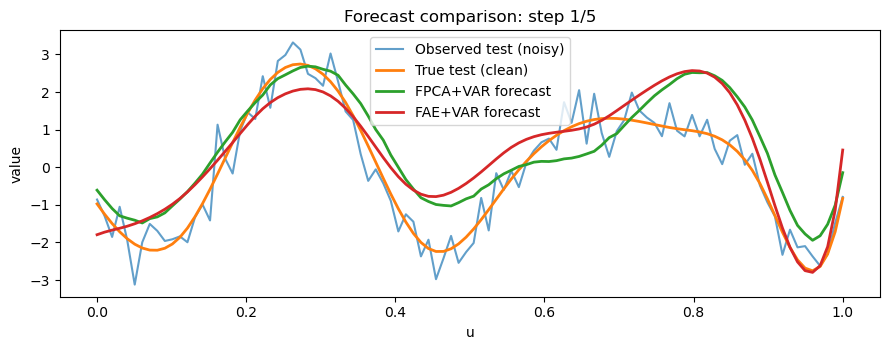

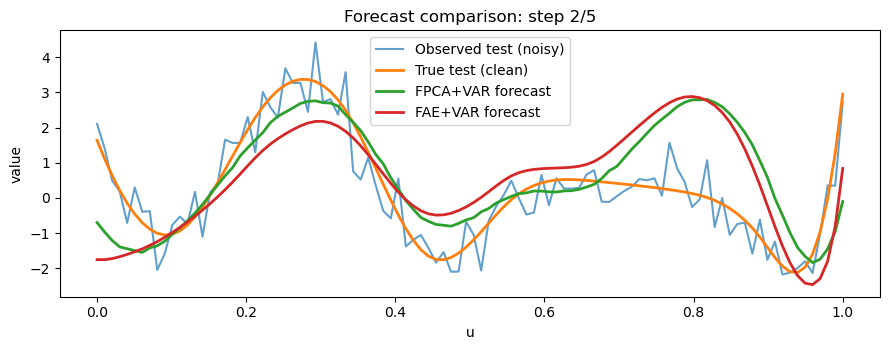

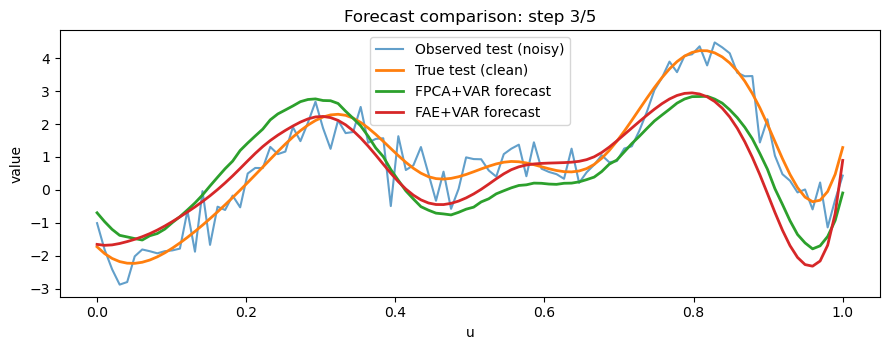

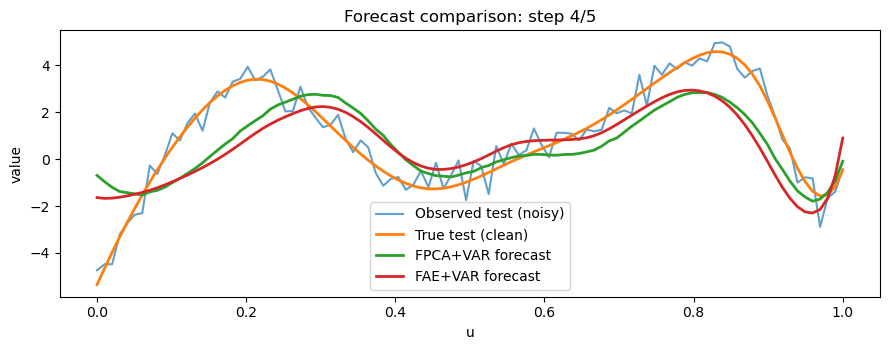

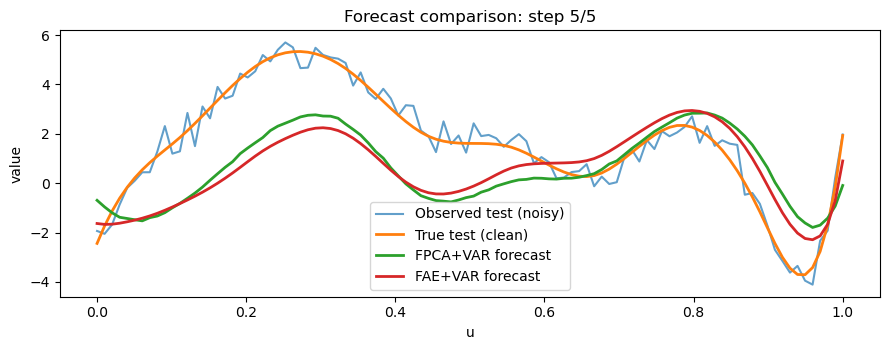

In [24]:
# Nonlinear Setup

if __name__ == "__main__":
    sim_cfg = SimCfg(
        seed=123,
        T=500,
        P=100,
        d=5,
        Sigma_scale=0.08,
        target_rho=0.85,
        gen_basis_type="Bspline",
        gen_n_basis=12,
        gen_bspline_degree=3,
        map_mode="nonlinear", 
        map_hidden=(64, 64),
        map_activation="relu",
        map_weight_sd=0.8,
        meas_noise_sd=0.5,
    )

    run_cfg = RunCfg(
        horizon=5,
        fpca_K=5,
        fpca_var_ridge=1e-8,
    )

    fae_cfg = FaeCfg(
        seed=743,
        device="cpu",
        n_basis_project=30,
        n_basis_revert=30,
        basis_type_project="Bspline",
        basis_type_revert="Bspline",
        bspline_degree=3,
        n_rep=5,
        init_weight_sd=0.5,
        epochs=2000,
        batch_size=16,
        lr=3e-4,
        weight_decay=1e-4,
        split_rate=0.85,
        log_every=200,
        pen="diff",
        lamb=0.001,
        var_ridge=1e-8,
    )

    run_two_reports(sim_cfg, run_cfg, fae_cfg)

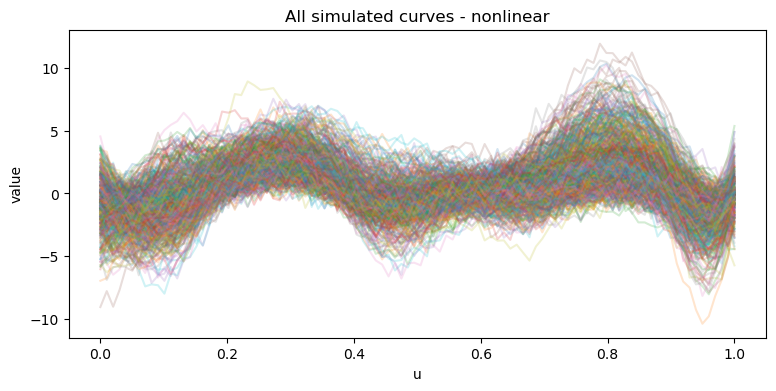

In [25]:
if __name__ == "__main__":
    sim_cfg = SimCfg(
        seed=123,
        T=500,
        P=100,
        d=5,
        Sigma_scale=0.08,
        target_rho=0.85,
        gen_basis_type="Bspline",
        gen_n_basis=12,
        gen_bspline_degree=3,
        map_mode="nonlinear", 
        map_hidden=(64, 64),
        map_activation="relu",
        map_weight_sd=0.8,
        meas_noise_sd=0.5,
    )

sim = simulate_functional_ts(sim_cfg)

u = sim["u"]
X_noisy = sim["X_noisy"]

plt.figure(figsize=(9,4))

for i in range(X_noisy.shape[0]):
    plt.plot(u, X_noisy[i].numpy(), alpha=0.2)

plt.title("All simulated curves - nonlinear")
plt.xlabel("u")
plt.ylabel("value")
plt.show()

Shapes:
  train: (495, 100)  test: (5, 100)  horizon: 5
[FAE] ep  200 | train_mse(noisy)=2.341573e-03 | val_mse(noisy)=3.718299e-03
[FAE] ep  400 | train_mse(noisy)=1.769710e-03 | val_mse(noisy)=2.653860e-03
[FAE] ep  600 | train_mse(noisy)=1.665246e-03 | val_mse(noisy)=2.324395e-03
[FAE] ep  800 | train_mse(noisy)=1.613550e-03 | val_mse(noisy)=2.138257e-03
[FAE] ep 1000 | train_mse(noisy)=1.591844e-03 | val_mse(noisy)=2.018061e-03
[FAE] ep 1200 | train_mse(noisy)=1.575780e-03 | val_mse(noisy)=1.933335e-03
[FAE] ep 1400 | train_mse(noisy)=1.564388e-03 | val_mse(noisy)=1.869690e-03
[FAE] ep 1600 | train_mse(noisy)=1.555966e-03 | val_mse(noisy)=1.816939e-03
[FAE] ep 1800 | train_mse(noisy)=1.549231e-03 | val_mse(noisy)=1.780014e-03
[FAE] ep 2000 | train_mse(noisy)=1.551471e-03 | val_mse(noisy)=1.750978e-03

REPORT 1 — Reconstruction on TRAIN
Method           relMSE vs CLEAN   relMSE vs NOISY
--------------------------------------------------
FPCA                    0.001831          0.01

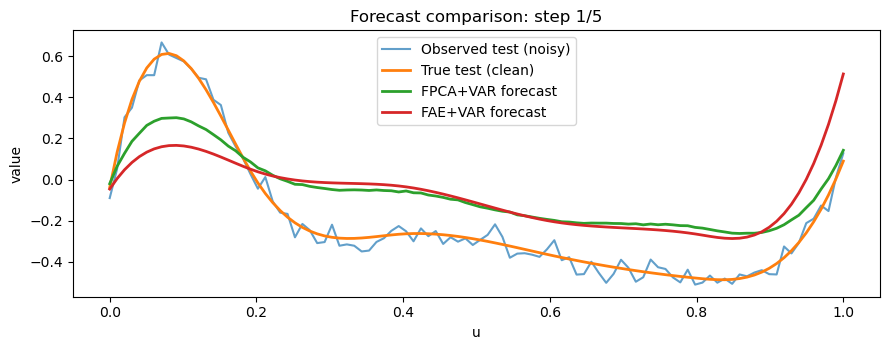

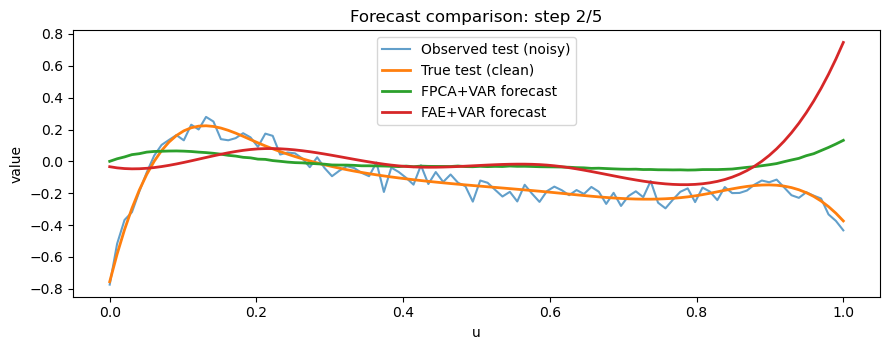

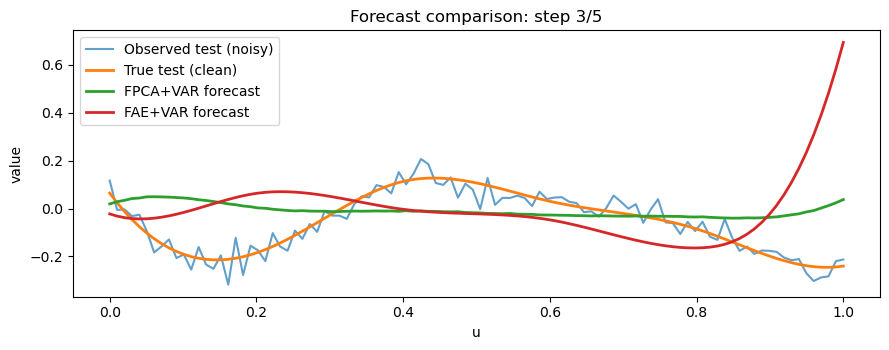

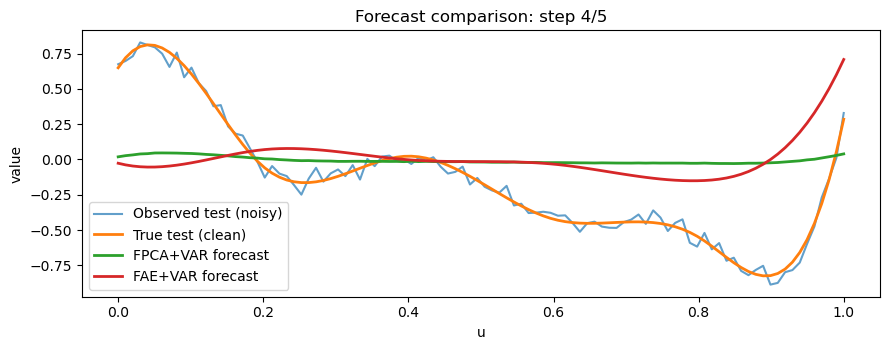

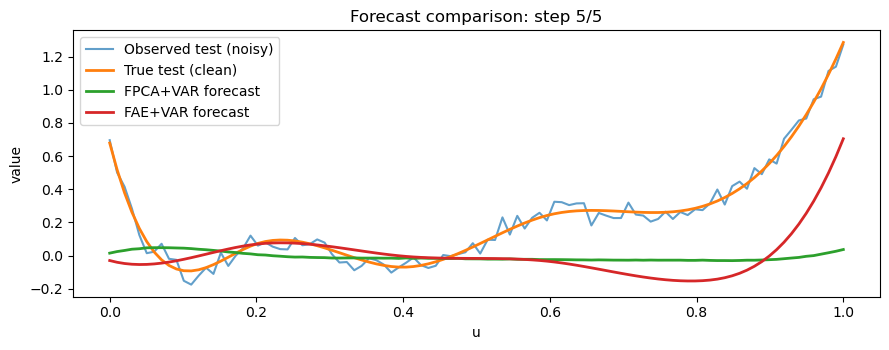

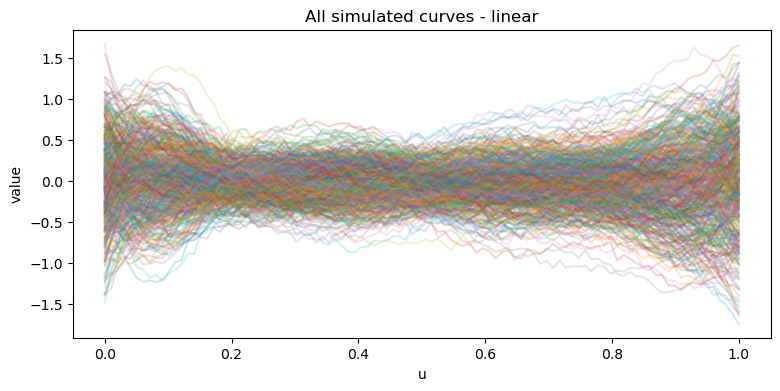

In [15]:
# Linear
if __name__ == "__main__":
    sim_cfg_lin = SimCfg(
        seed=123,
        T=500,
        P=100,
        d=5,
        Sigma_scale=0.08,
        target_rho=0.85,
        gen_basis_type="Bspline",
        gen_n_basis=8,
        gen_bspline_degree=3,
        map_mode="linear", 
        map_hidden=(64, 64),
        map_activation="relu",
        map_weight_sd=0.8,
        meas_noise_sd=0.04,
    )

    run_cfg = RunCfg(
        horizon=5,
        fpca_K=8,
        fpca_var_ridge=1e-8,
    )

    fae_cfg = FaeCfg(
        seed=743,
        device="cpu",
        n_basis_project=sim_cfg_lin.gen_n_basis,    
        n_basis_revert=sim_cfg_lin.gen_n_basis,   
        basis_type_project=sim_cfg_lin.gen_basis_type, 
        basis_type_revert=sim_cfg_lin.gen_basis_type, 
        bspline_degree=sim_cfg_lin.gen_bspline_degree,
        n_rep=8,
        init_weight_sd=0.5,
        epochs=2000,
        batch_size=16,
        lr=3e-4,
        weight_decay=1e-6,
        split_rate=0.85,
        log_every=200,
        pen="diff",
        lamb=1e-6,
        var_ridge=1e-8,
    )

    run_two_reports(sim_cfg_lin, run_cfg, fae_cfg)

sim_lin = simulate_functional_ts(sim_cfg_lin)

u_lin = sim_lin["u"]
X_noisy_lin = sim_lin["X_noisy"]

plt.figure(figsize=(9,4))

for i in range(X_noisy_lin.shape[0]):
    plt.plot(u_lin, X_noisy_lin[i].numpy(), alpha=0.2)

plt.title("All simulated curves - linear")
plt.xlabel("u")
plt.ylabel("value")
plt.show()

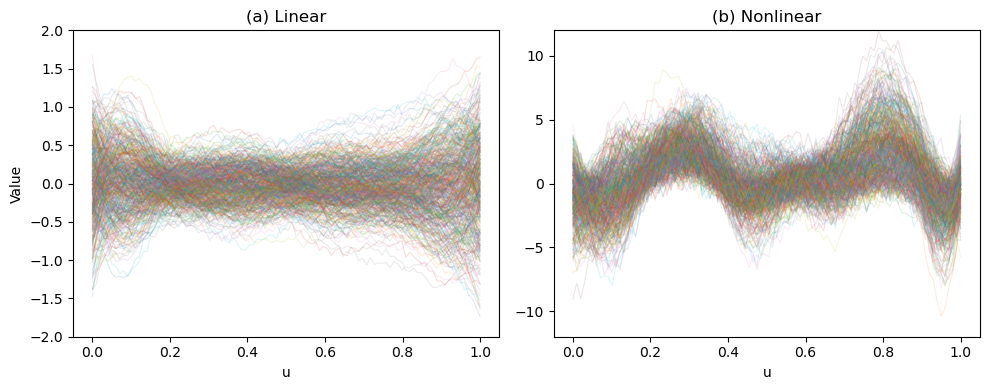

In [4]:
# Linear
if __name__ == "__main__":
    sim_cfg_lin = SimCfg(
        seed=123,
        T=500,
        P=100,
        d=5,
        Sigma_scale=0.08,
        target_rho=0.85,
        gen_basis_type="Bspline",
        gen_n_basis=8,
        gen_bspline_degree=3,
        map_mode="linear", 
        map_hidden=(64, 64),
        map_activation="relu",
        map_weight_sd=0.8,
        meas_noise_sd=0.04,
    )


sim_lin = simulate_functional_ts(sim_cfg_lin)

u_lin = sim_lin["u"]
X_noisy_lin = sim_lin["X_noisy"]
# Nonlinear Setup

if __name__ == "__main__":
    sim_cfg_nonlin = SimCfg(
        seed=123,
        T=500,
        P=100,
        d=5,
        Sigma_scale=0.08,
        target_rho=0.85,
        gen_basis_type="Bspline",
        gen_n_basis=12,
        gen_bspline_degree=3,
        map_mode="nonlinear", 
        map_hidden=(64, 64),
        map_activation="relu",
        map_weight_sd=0.8,
        meas_noise_sd=0.5,
    )

sim_nonlin = simulate_functional_ts(sim_cfg_nonlin)

u_nonlin = sim_nonlin["u"]
X_noisy_nonlin = sim_nonlin["X_noisy"]


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---- Linear ----
for i in range(X_noisy_lin.shape[0]):
    axes[0].plot(u_lin, X_noisy_lin[i].numpy(), alpha=0.15, lw=0.8)

axes[0].set_title("(a) Linear")
axes[0].set_xlabel("u")
axes[0].set_ylabel("Value")

axes[0].set_ylim(-2, 2)


# ---- Nonlinear ----
for i in range(X_noisy_nonlin.shape[0]):
    axes[1].plot(u_nonlin, X_noisy_nonlin[i].numpy(), alpha=0.15, lw=0.8)

axes[1].set_title("(b) Nonlinear")
axes[1].set_xlabel("u")

# keep full scale
axes[1].set_ylim(-12, 12)


plt.tight_layout()

plt.savefig("functional_ts_simulation.pdf", bbox_inches="tight")

plt.show()